In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.patches import Rectangle
from datetime import datetime 
import dask

In [2]:
from OceanDataStore import OceanDataCatalog

In [3]:
catalog = OceanDataCatalog(catalog_name="noc-model-stac")

In [4]:
catalog.available_collections

['noc-rapid-evolution', 'noc-npd-jra55', 'noc-npd-era5']

In [5]:
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [6]:
catalog.available_items

['noc-npd-era5/npd-eorca1-era5v1/gn/T1y',
 'noc-npd-era5/npd-eorca1-era5v1/gn/T1m',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T1m_3d',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T5d_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T1m_3d']

In [7]:
catalog.Items[4]

<Item id=noc-npd-era5/npd-eorca025-era5v1/gn/T5d_3d>

In [8]:
ds1 = catalog.open_dataset(id=catalog.Items[4].id,
                          start_datetime='1976-01',
                          end_datetime='2024-12', 
                          bbox = (-85.0, 0.0, 0.0, 80.0))

In [9]:
max_region = ds1.sel(time_counter = ds1['time_counter'].dt.month.isin([8, 9]))
grouped = max_region['tos_con'].groupby('time_counter.year')
max_temp = (grouped.max(dim='time_counter')).compute()

C:\Users\TomAH\anaconda3\envs\env_ods\Lib\site-packages\dask\array\reductions.py:325: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
C:\Users\TomAH\anaconda3\envs\env_ods\Lib\site-packages\dask\array\reductions.py:325: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


In [10]:
max_temp

<xarray.DataArray 'tos_con' (year: 35, y: 482, x: 341)> Size: 23MB
array([[[      nan, 25.626534, 25.632574, ..., 26.55032 , 26.568916,
         26.578579],
        [      nan, 25.763966, 25.773159, ..., 26.61919 , 26.626041,
         26.62189 ],
        [      nan, 25.843348, 25.8698  , ..., 26.65769 , 26.645967,
         26.64375 ],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan, 25.719183, 25.675066, ..., 26.735895, 26.746372,
         26.76754 ],
        [      nan, 25.865925, 25.852617, ..., 26.850525, 26.856205,
         26.866455],
        [      nan, 25.950642, 25.957224, ..., 26.907728, 26.919899,
         26.923264],
...
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan, 25.903074, 25.899872, ..., 27.130266, 27.18088 ,
         27.206728],
        [      nan, 26.097054, 26.13448 , ..., 27.185513, 27.211323,
         27.225445],
        [      nan, 26.308653, 26.368706, ..., 27.170353, 27.201332,
         27.225777],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], shape=(35, 482, 341), dtype=float32)
Coordinates:
    nav_lon  (y, x) float64 1MB -85.0 -84.75 -84.5 -84.25 ... 48.28 48.54 48.79
    nav_lat  (y, x) float64 1MB 0.0 0.0 0.0 0.0 0.0 ... 79.51 79.41 79.3 79.2
  * year     (year) int64 280B 1990 1991 1992 1993 1994 ... 2021 2022 2023 2024
Dimensions without coordinates: y, x
Attributes:
    standard_name:       sea_surface_temperature
    long_name:           sea_surface_conservative_temperature
    units:               degC
    online_operation:    average
    interval_operation:  1800 s
    interval_write:      5 d
    cell_methods:        time: mean (interval: 1800 s)

In [11]:
## Calculating map of trend magnitudes 

ny, nx = max_temp.sizes['y'], max_temp.sizes['x']
trend_data = np.full((ny, nx), np.nan, dtype=np.float32)

for y_idx in range (ny):
    for x_idx in range (nx):
        point = max_temp.isel(y=y_idx, x=x_idx)
        try:
            z = np.polyfit(point['year'], point.values, 1)
            trend_data[y_idx, x_idx] = z[0]
        except:
            trend_data[y_idx, x_idx] = np.nan

trend_da = xr.DataArray(data = trend_data, dims=["y", "x"], 
        coords={ "y": max_temp['y'],
        "x": max_temp['x'],
        "nav_lat": (("y", "x"), max_temp['nav_lat'].values),
        "nav_lon": (("y", "x"), max_temp['nav_lon'].values)}, name="trend",
        attrs={"description": "Linear trend over time of SST Maximum"})
        

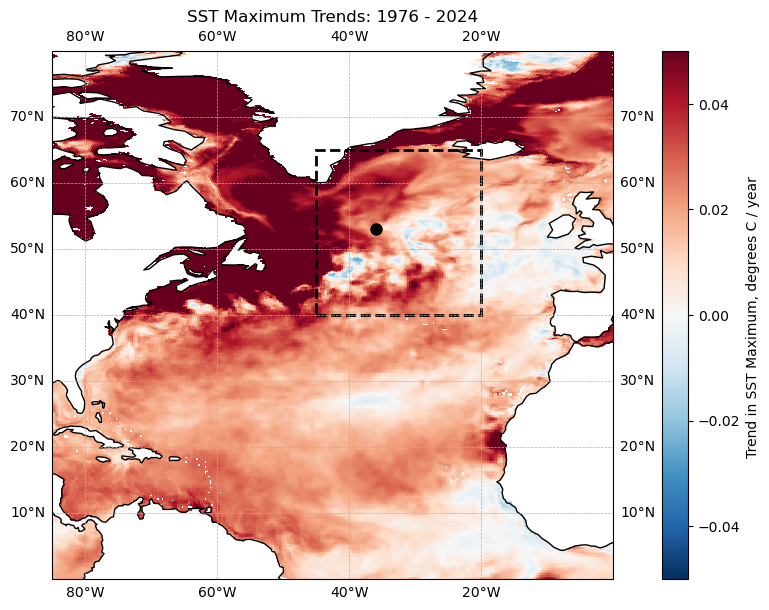

In [12]:
## Plotting Map of Trend Magnitude

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10, 6))
im = ax.pcolormesh(trend_da['nav_lon'], trend_da['nav_lat'], trend_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin= -0.05, vmax=0.05)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', 
                facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, label='Trend in SST Maximum, degrees C / year ')
plt.tight_layout()
title = ax.set_title('SST Maximum Trends: 1976 - 2024')